# 📊 Complete Statistics + Visualization Notebook
Includes: Beginner → Advanced concepts with Iris & Titanic datasets

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, poisson, skew, kurtosis
from sklearn.datasets import load_iris
import seaborn as sns

# Load datasets
iris = load_iris(as_frame=True)
iris_df = iris.frame

titanic_df = sns.load_dataset("titanic")

print("Iris shape:", iris_df.shape)
print("Titanic shape:", titanic_df.shape)


Iris shape: (150, 5)
Titanic shape: (891, 15)


## 🟢 Basic Statistics

In [2]:
data = iris_df['sepal length (cm)']

mean = np.mean(data)
median = np.median(data)
variance = np.var(data)
std_dev = np.std(data)

print("Mean:", mean)
print("Median:", median)
print("Variance:", variance)
print("Std Dev:", std_dev)


Mean: 5.843333333333334
Median: 5.8
Variance: 0.6811222222222223
Std Dev: 0.8253012917851409


## 📊 Histogram

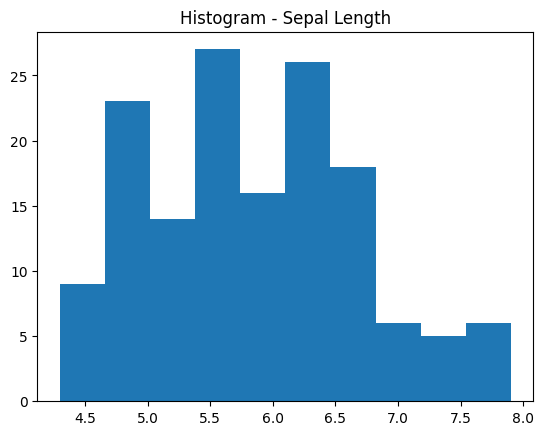

In [3]:
plt.figure()
plt.hist(data)
plt.title("Histogram - Sepal Length")
plt.show()


## 📦 Boxplot

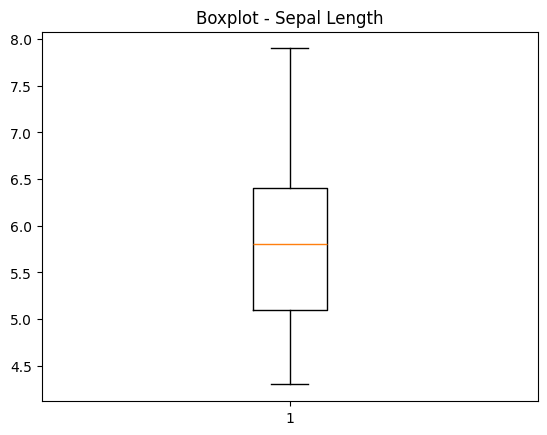

In [4]:
plt.figure()
plt.boxplot(data)
plt.title("Boxplot - Sepal Length")
plt.show()


## 🔔 Normal Distribution

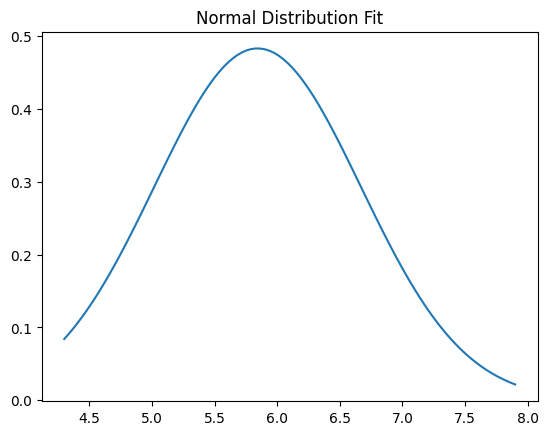

In [5]:
x = np.linspace(min(data), max(data), 100)
y = norm.pdf(x, mean, std_dev)

plt.figure()
plt.plot(x, y)
plt.title("Normal Distribution Fit")
plt.show()


## 🔗 Correlation Matrix

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


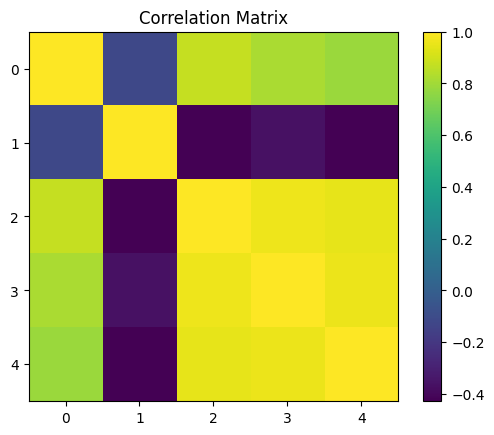

In [6]:
corr = iris_df.corr()
print(corr)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


## 📐 Skewness & Kurtosis

In [7]:
print("Skewness:", skew(data))
print("Kurtosis:", kurtosis(data))


Skewness: 0.3117530585022963
Kurtosis: -0.5735679489249765


## 🎯 Binomial Distribution

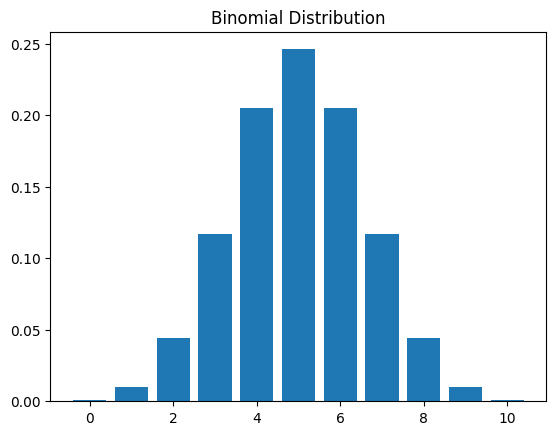

In [8]:
n, p = 10, 0.5
x = np.arange(0, 11)
y = binom.pmf(x, n, p)

plt.figure()
plt.bar(x, y)
plt.title("Binomial Distribution")
plt.show()


## 📌 Poisson Distribution

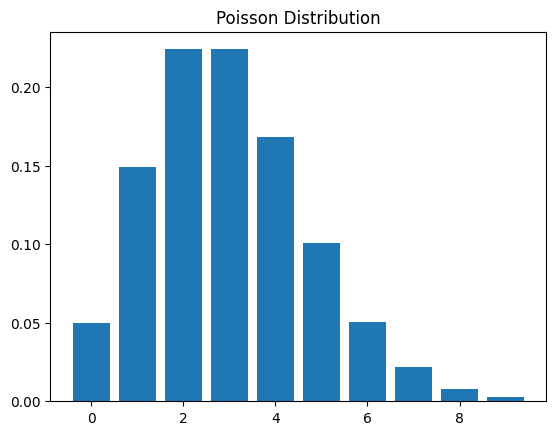

In [9]:
lam = 3
x = np.arange(0, 10)
y = poisson.pmf(x, lam)

plt.figure()
plt.bar(x, y)
plt.title("Poisson Distribution")
plt.show()


## 🚢 Titanic Survival Analysis

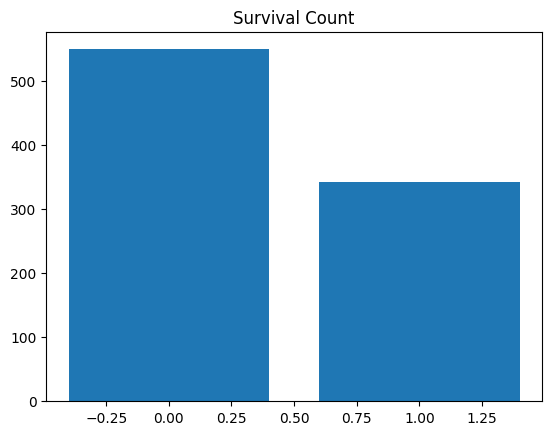

In [10]:
survival_counts = titanic_df['survived'].value_counts()

plt.figure()
plt.bar(survival_counts.index, survival_counts.values)
plt.title("Survival Count")
plt.show()


## 📈 Density Plot

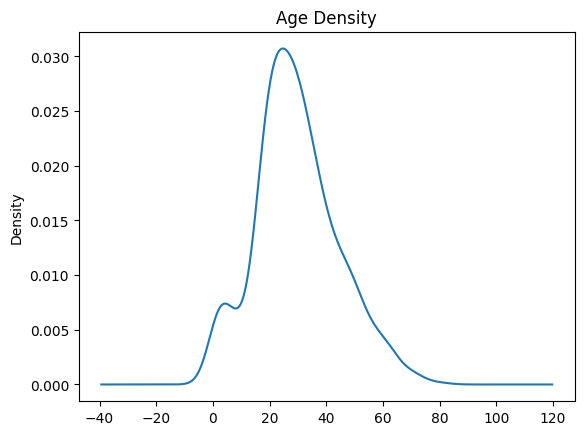

In [11]:
titanic_df['age'].dropna().plot(kind='density')
plt.title("Age Density")
plt.show()


# Gaussian vs Log-Normal (Iris)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, probplot
from sklearn.datasets import load_iris
# ===============================
# 📥 2. Load Iris Dataset
# ===============================
iris = load_iris(as_frame=True)
df = iris.frame

# Use one feature (continuous)
data = df['sepal length (cm)']

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [6]:
mean = np.mean(data)
std = np.std(data)

print("Mean:", mean)
print("Std Dev:", std)

Mean: 5.843333333333334
Std Dev: 0.8253012917851409


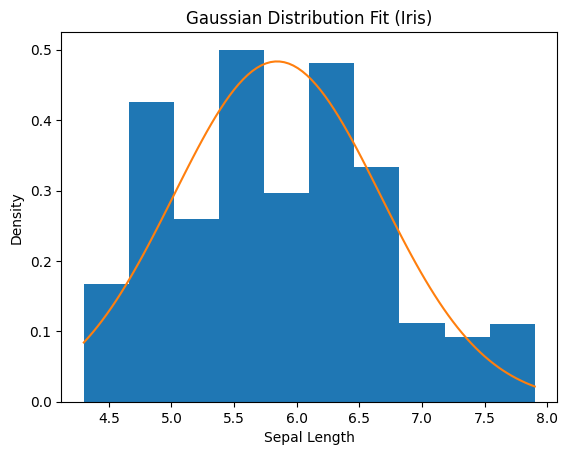

In [7]:
# Create x values
x = np.linspace(min(data), max(data), 100)

# Normal PDF
normal_pdf = norm.pdf(x, mean, std)

plt.figure()
plt.hist(data, density=True)   # histogram
plt.plot(x, normal_pdf)        # normal curve
plt.title("Gaussian Distribution Fit (Iris)")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.show()

In [8]:
log_data = np.log(data)

log_mean = np.mean(log_data)
log_std = np.std(log_data)

print("Log Mean:", log_mean)
print("Log Std:", log_std)

Log Mean: 1.7553928801922802
Log Std: 0.14071764850448856


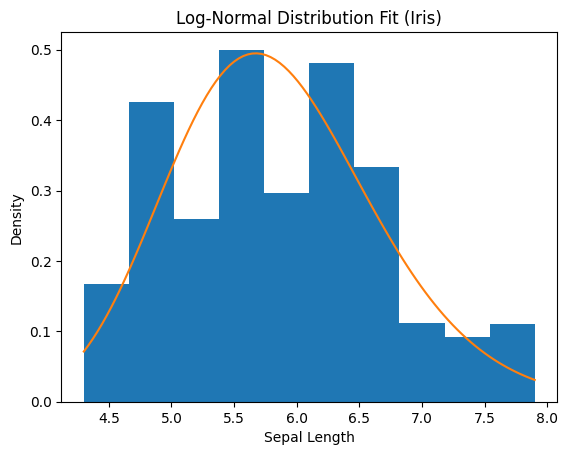

In [9]:
# Log-normal PDF
log_pdf = lognorm.pdf(x, s=log_std, scale=np.exp(log_mean))

plt.figure()
plt.hist(data, density=True)
plt.plot(x, log_pdf)
plt.title("Log-Normal Distribution Fit (Iris)")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.show()

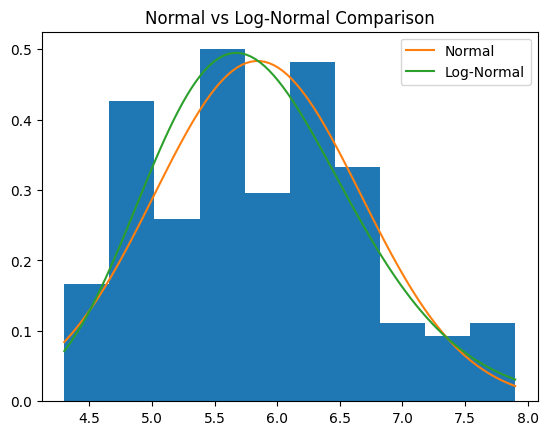

In [10]:
plt.figure()

plt.hist(data, density=True)

# Normal
plt.plot(x, normal_pdf, label="Normal")

# Log-normal
plt.plot(x, log_pdf, label="Log-Normal")

plt.legend()
plt.title("Normal vs Log-Normal Comparison")
plt.show()

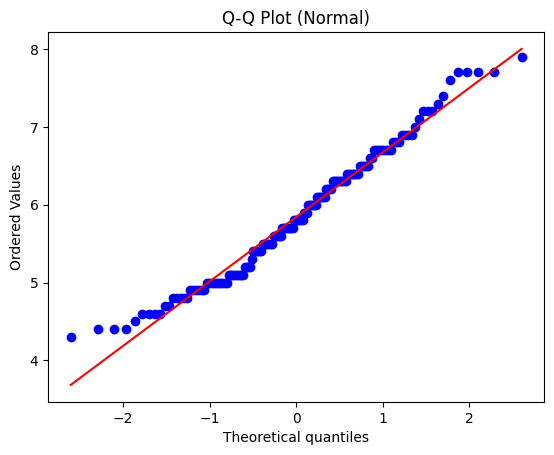

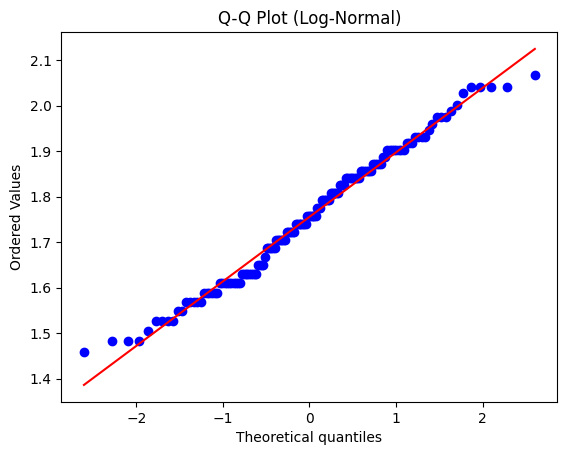

In [11]:
# Normal Q-Q Plot
plt.figure()
probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot (Normal)")
plt.show()

# Log Q-Q Plot
plt.figure()
probplot(log_data, dist="norm", plot=plt)
plt.title("Q-Q Plot (Log-Normal)")
plt.show()